# Tech Industry Layoffs Analysis (2020–2025)

An exploratory data analysis of global tech layoffs using a dataset of 
2,412 records across 18 variables, covering companies worldwide from 
2020 to 2025.

## 1. Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Data Cleaning

### 2.1 Initial Data Exploration

In [2]:
df_original = pd.read_csv("tech_layoffs_til_2025.csv")

In [3]:
df_original.head()

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862


In [4]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nr                           2412 non-null   int64  
 1   Company                      2412 non-null   object 
 2   Location_HQ                  2412 non-null   object 
 3   Region                       2412 non-null   object 
 4   USState                      2411 non-null   object 
 5   Country                      2412 non-null   object 
 6   Continent                    2412 non-null   object 
 7   Laid_Off                     2040 non-null   float64
 8   Date_layoffs                 2412 non-null   object 
 9   Percentage                   1963 non-null   float64
 10  Company_Size_before_Layoffs  1769 non-null   float64
 11  Company_Size_after_layoffs   1857 non-null   float64
 12  Industry                     2412 non-null   object 
 13  Stage             

In [5]:
df_original.shape

(2412, 18)

In [6]:
df_original.columns

Index(['Nr', 'Company', 'Location_HQ', 'Region', 'USState', 'Country',
       'Continent', 'Laid_Off', 'Date_layoffs', 'Percentage',
       'Company_Size_before_Layoffs', 'Company_Size_after_layoffs', 'Industry',
       'Stage', 'Money_Raised_in__mil', 'Year', 'latitude', 'longitude'],
      dtype='object')

### 2.2 Null Value Analysis


In [7]:
df_limpio = df_original.copy()

In [8]:
#Total nulls per columns
nulls = df_limpio.isnull().sum()
print (nulls)

Nr                               0
Company                          0
Location_HQ                      0
Region                           0
USState                          1
Country                          0
Continent                        0
Laid_Off                       372
Date_layoffs                     0
Percentage                     449
Company_Size_before_Layoffs    643
Company_Size_after_layoffs     555
Industry                         0
Stage                          164
Money_Raised_in__mil           364
Year                             0
latitude                         0
longitude                        0
dtype: int64


In [9]:
# Total nulls and percentage per column
nulls_pct = (nulls / len(df_limpio) * 100).round(2)
df_nulls = pd.DataFrame({'Quantity': nulls, 'Percentage (%)': nulls_pct})
print('Null values per column:')
display(df_nulls[df_nulls['Quantity'] > 0])
print(f'\nTotal columns with null values: {(nulls > 0).sum()}')

Null values per column:


,Quantity,Percentage (%)
USState,1,0.04
Laid_Off,372,15.42
Percentage,449,18.62
Company_Size_before_Layoffs,643,26.66
Company_Size_after_layoffs,555,23.01
Stage,164,6.80
Money_Raised_in__mil,364,15.09



Total columns with null values: 7


### 2.3 Null Value Decisions

- **Laid_Off**: 15.42% missing — key column, rows will be excluded 
  when analyzing layoff numbers
- **Percentage**: 18.62% missing — will use available subset only
- **Company_Size_before/after**: 26%/23% missing — high missingness, 
  will use where available for size analysis
- **Stage**: 6.80% missing — will fill with "Unknown"
- **Money_Raised_in__mil**: 15.09% missing — not all funding data is 
  public, will use available subset
- **USState**: 0.04% missing — negligible, no action needed

In [10]:
# filling 'Stage' column nulls 
df_limpio['Stage'] = df_limpio['Stage'].fillna("Unknown")

In [11]:
df_limpio['Stage'].isnull().sum()

np.int64(0)

## 3. Descriptive Statistics

Key observation: Laid_Off, Company_Size_before/after, and Money_Raised_in__mil 
all show high right skew — mean significantly higher than median — driven by 
a few massive events (large enterprises, heavily funded startups). 
Median is a more representative measure of central tendency for these variables.


In [12]:
round(df_limpio.describe(),2)

,Nr,Laid_Off,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Money_Raised_in__mil,Year,latitude,longitude
count,2412.00,2040.00,1963.00,1769.00,1857.00,2048.00,2412.00,2412.00,2412.00
mean,1206.50,366.08,26.16,4490.32,3962.73,683.78,2022.91,35.02,-58.67
std,696.43,1406.97,27.42,26452.74,25047.52,4292.58,1.52,16.76,74.27
min,1.00,1.00,0.00,0.00,0.00,0.00,2020.00,-41.29,-123.26
25%,603.75,40.00,9.60,215.00,121.00,50.00,2022.00,34.05,-122.16
50%,1206.50,95.00,16.00,571.00,402.00,161.00,2023.00,37.78,-79.38
75%,1809.25,200.00,30.00,1538.00,1221.00,451.25,2024.00,42.36,-0.14
max,2412.00,30000.00,100.00,600000.00,588000.00,121900.00,2025.00,60.20,174.78


## 4. Exploratory Data Analysis

### 4.1 Total Layoffs by Year

2021 shows minimal layoffs — tech companies were in a hiring boom driven by 
pandemic-era digital demand. The sharp increase in 2022-2023 reflects the 
post-COVID correction, as companies over-hired and faced rising interest rates 
and slowing growth.

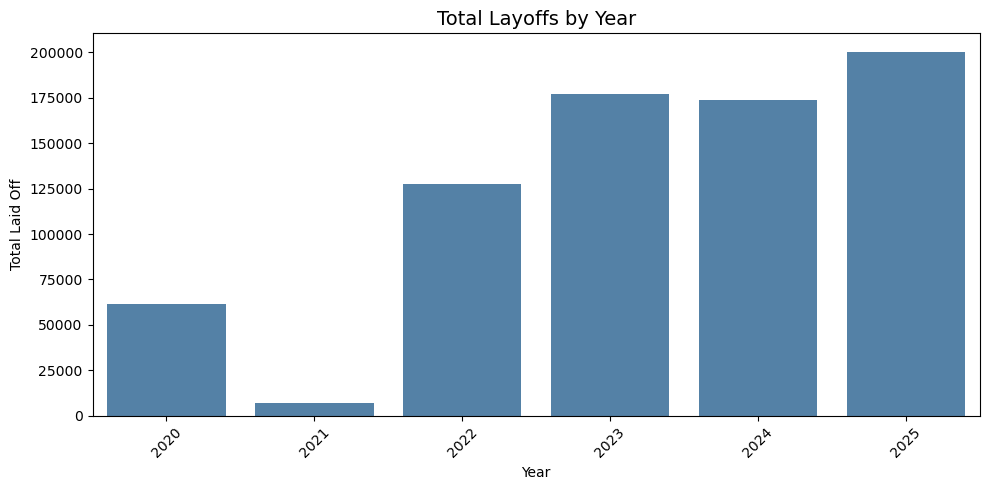

In [13]:
layoffs_by_year = df_limpio.groupby('Year')['Laid_Off'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=layoffs_by_year, x='Year', y='Laid_Off', color='steelblue')
plt.title('Total Layoffs by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Laid Off')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 4.2 Top 10 Industries by Total Layoffs

Consumer and Retail sectors lead total layoffs, reflecting their large workforce 
size and post-pandemic over-expansion in e-commerce and digital services.

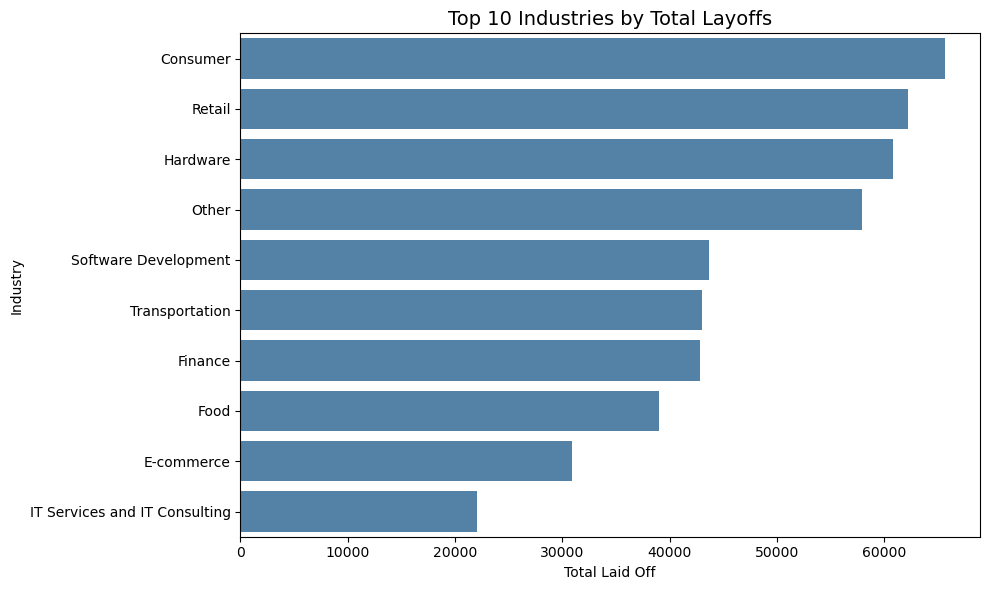

In [14]:
top_industries = (df_limpio.dropna(subset=['Laid_Off'])
                  .groupby('Industry')['Laid_Off']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=top_industries, x='Laid_Off', y='Industry', color='steelblue')
plt.title('Top 10 Industries by Total Layoffs', fontsize=14)
plt.xlabel('Total Laid Off')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

### 4.3 Top 10 Countries by Total Layoffs

USA dominates, dwarfing all other countries — reflecting its concentration of 
major tech headquarters. India ranks second, driven by large office presence 
from US-based companies. Ireland's appearance in the top 10 is notable, as many 
big tech companies (Google, Meta, Apple) use it as their European headquarters.

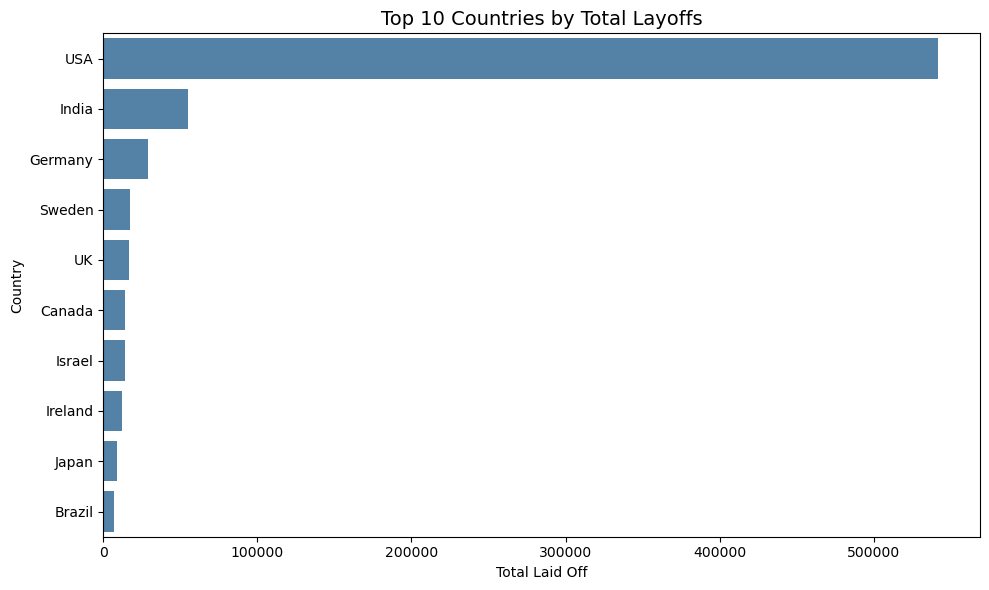

In [15]:
top_countries = (df_limpio.dropna(subset=['Laid_Off'])
                 .groupby('Country')['Laid_Off']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x='Laid_Off', y='Country', color='steelblue')
plt.title('Top 10 Countries by Total Layoffs', fontsize=14)
plt.xlabel('Total Laid Off')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### 4.4 Top 10 Companies by Total Layoffs

Amazon, Intel, and Microsoft lead in absolute layoff numbers, reflecting their 
massive workforce size. Large absolute numbers don't necessarily mean higher 
layoff rates — a 5% cut at Amazon affects more people than a 30% cut at a 
small startup.

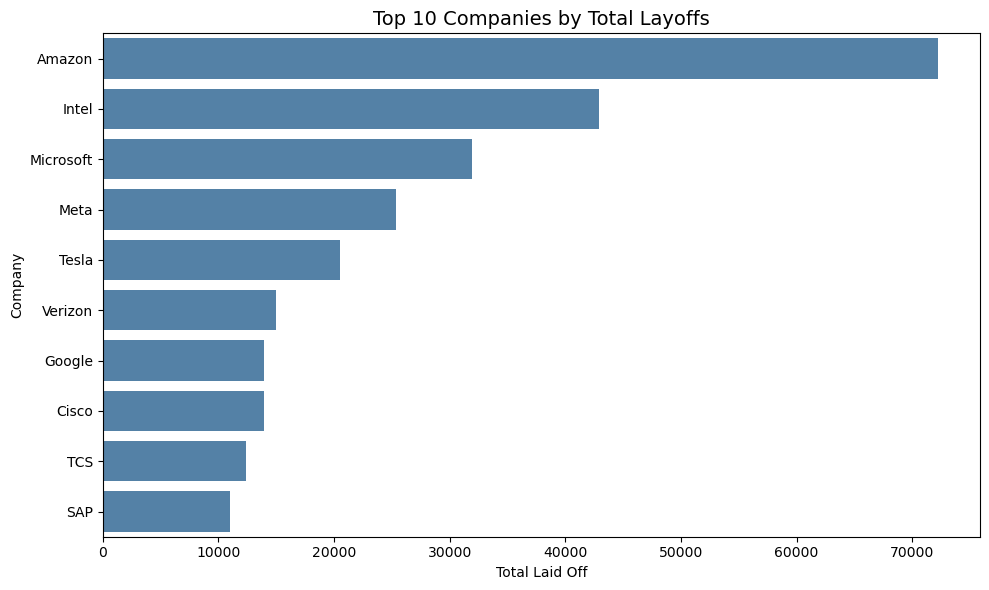

In [16]:
top_companies = (df_limpio.dropna(subset=['Laid_Off'])
                 .groupby('Company')['Laid_Off']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=top_companies, x='Laid_Off', y='Company', color='steelblue')
plt.title('Top 10 Companies by Total Layoffs', fontsize=14)
plt.xlabel('Total Laid Off')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

### 4.5 Layoffs by Month

January, April, and November concentrate the most layoffs, reflecting corporate 
planning cycles. January layoffs execute Q4 restructuring decisions. November cuts 
align with year-end budget planning. April spikes follow Q1 earnings reports, when 
companies adjust headcount based on financial performance.

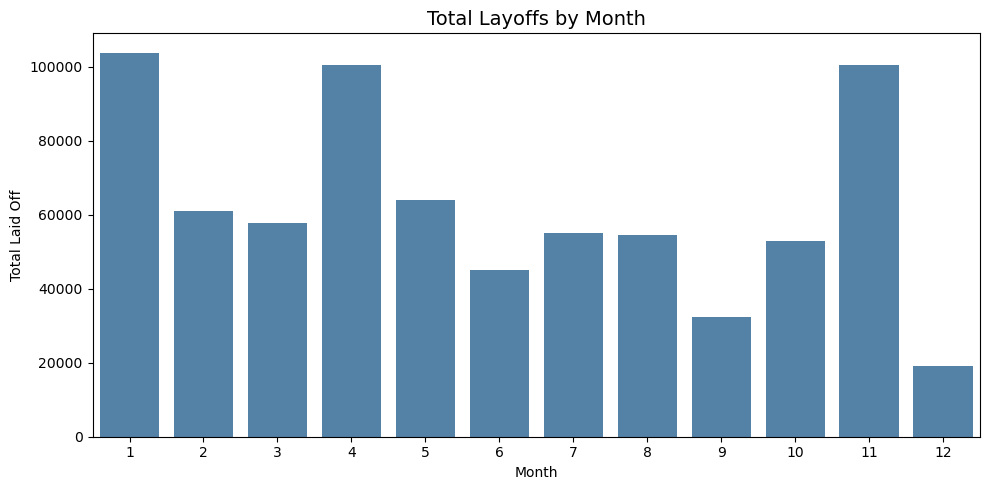

In [17]:
df_limpio['Date_layoffs'] = pd.to_datetime(df_limpio['Date_layoffs'])
df_limpio['Month'] = df_limpio['Date_layoffs'].dt.month

layoffs_by_month = (df_limpio.dropna(subset=['Laid_Off'])
                    .groupby('Month')['Laid_Off']
                    .sum()
                    .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=layoffs_by_month, x='Month', y='Laid_Off', color='steelblue')
plt.title('Total Layoffs by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Laid Off')
plt.tight_layout()
plt.show()

### 4.6 Layoffs by Year and Industry (Top 10)

2022-2023 were dominated by Consumer and Retail layoffs, reflecting the 
post-pandemic e-commerce correction. By 2024-2025 the pattern shifted toward 
core tech sectors — Hardware, Software, E-commerce, and IT Consulting — suggesting 
the wave moved into the foundational tech industry itself, likely accelerated 
by AI automation replacing traditional tech roles.

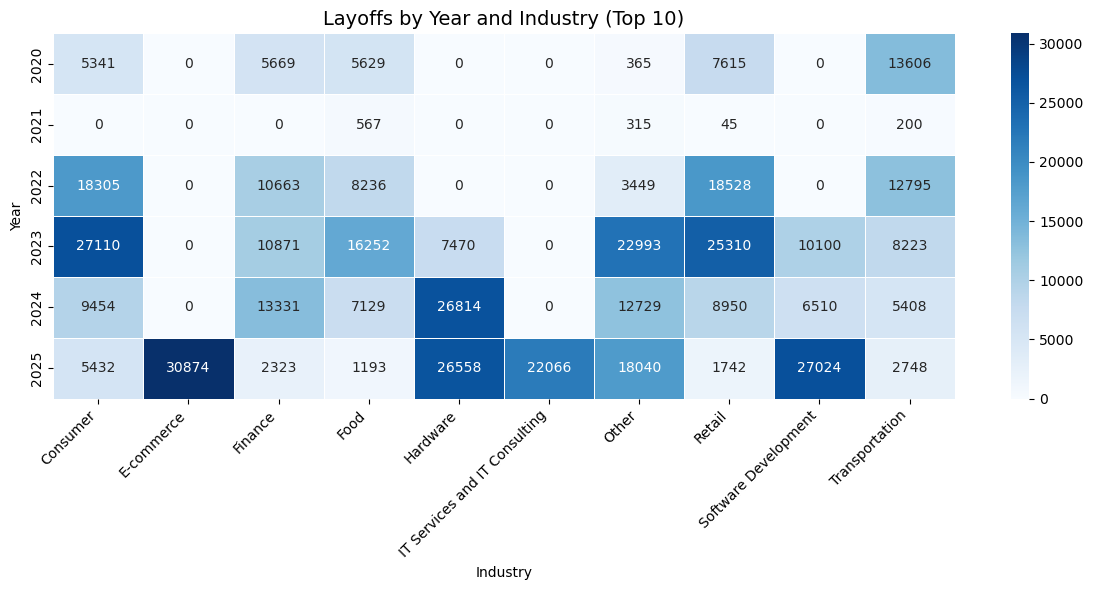

In [18]:
top_10_industries = (df_limpio.dropna(subset=['Laid_Off'])
                     .groupby('Industry')['Laid_Off']
                     .sum()
                     .sort_values(ascending=False)
                     .head(10)
                     .index)

pivot_top10 = (df_limpio[df_limpio['Industry'].isin(top_10_industries)]
               .dropna(subset=['Laid_Off'])
               .groupby(['Year', 'Industry'])['Laid_Off']
               .sum()
               .unstack(fill_value=0))

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_top10, cmap='Blues', annot=True, fmt='.0f', linewidths=0.5)
plt.title('Layoffs by Year and Industry (Top 10)', fontsize=14)
plt.xlabel('Industry')
plt.ylabel('Year')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Conclusions

## Key Findings

**1. The Post-COVID Correction**
Tech layoffs exploded in 2022-2023 after a massive pandemic-era hiring 
boom. Companies over-hired during the digital surge of 2020-2021 and 
were forced to correct as growth slowed and interest rates rose.

**2. USA Dominates**
The United States accounts for the vast majority of global tech layoffs, 
reflecting its concentration of major tech headquarters. India and Germany 
follow distantly, driven by large offshore offices of US-based companies.

**3. Industry Shift**
Early layoffs (2022-2023) hit Consumer and Retail hardest — the 
post-pandemic e-commerce correction. By 2024-2025 the wave moved into 
core tech: Hardware, Software, E-commerce, and IT Consulting, suggesting 
structural changes driven by AI automation.

**4. Big Companies, Big Numbers**
Amazon, Intel, and Microsoft lead in absolute layoff numbers due to their 
massive workforce size. However, absolute numbers don't reflect layoff 
rates — a 5% cut at Amazon affects more people than a 50% cut at a startup.

**5. Corporate Cycles Drive Timing**
January, April, and November concentrate the most layoffs, aligned with 
fiscal year planning, Q1 earnings reports, and year-end budget decisions.